In [36]:
# Import required modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [37]:
# Set plot parameter
#plt.rcParams['figure.figsize'] = (10, 7.5)

In [38]:
# Read data file
url = 'https://raw.githubusercontent.com/faadeola/oil_prices_ts_analysis/refs/heads/main/oil_prices_2426.csv'
# Read file for analysis
oil = pd.read_csv(url, parse_dates=['date'], dayfirst=True)

# Save a copy of the data
oil_dup = pd.read_csv(url, parse_dates=['date'], dayfirst=True)

In [39]:
# display sample of data
oil.sample(10)

,date,price (dollars)
379,2025-10-05,115.59
225,2025-05-04,54.25
267,2025-06-15,69.25
47,2024-11-07,35.70
275,2025-06-23,80.43
212,2025-04-21,57.05
217,2025-04-26,59.28
314,2025-08-01,107.96
407,2025-11-02,131.11
103,2025-01-02,24.08


In [40]:
# Display shape of the data
print(f'The oil data consist of {oil.shape[0]} rows and {oil.shape[1]} columns')

The oil data consist of 500 rows and 2 columns


In [41]:
oil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             500 non-null    datetime64[ns]
 1   price (dollars)  500 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 7.9 KB


In [42]:
# Display summary statistics of the data
oil.describe().round(2)

,date,price (dollars)
count,500,500.00
mean,2025-05-28 12:00:00,75.87
min,2024-09-21 00:00:00,16.48
25%,2025-01-23 18:00:00,35.37
50%,2025-05-28 12:00:00,64.29
75%,2025-09-30 06:00:00,111.57
max,2026-02-02 00:00:00,158.78
std,NaN,42.91


In [43]:
# set date as the index column
oil = oil.set_index('date')

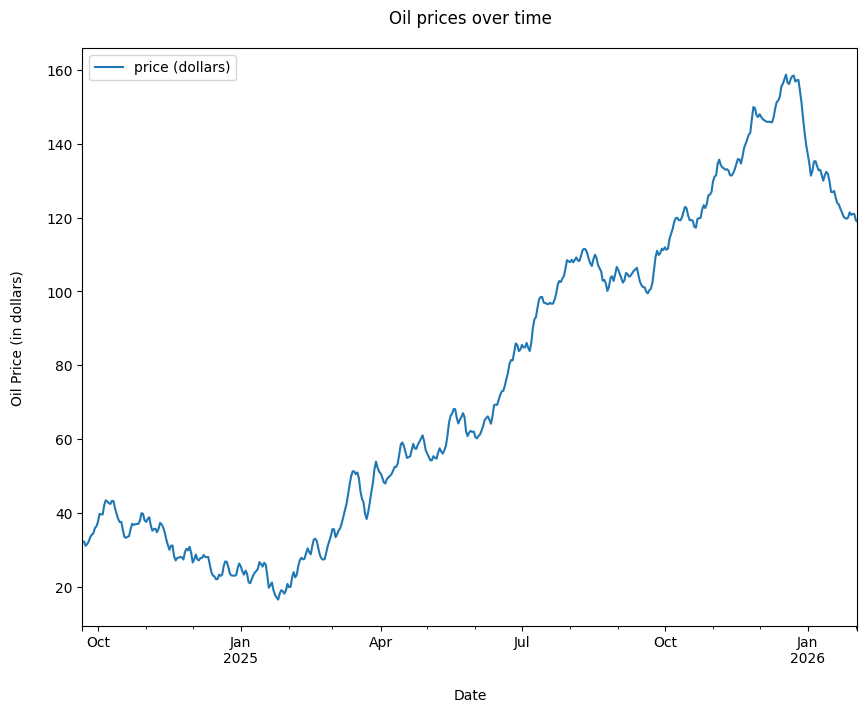

In [44]:
# Plot chart of oil prices overtime
oil.plot()
plt.title('Oil prices over time', pad=18)
plt.legend(loc='best')
plt.ylabel('Oil Price (in dollars)', labelpad=16)
plt.xlabel('Date', labelpad=16)
plt.show()

In [45]:
# Get month and year of each data point
oil_dup['month'] = oil_dup['date'].dt.month.astype('str')
oil_dup['year'] = oil_dup['date'].dt.year

In [46]:
month_dict = {
    '1':'January',
    '2':'February',
    '3':'March',
    '4':'April',
    '5':'May',
    '6':'June',
    '7':'July',
    '8':'August',
    '9':'September',
    '10':'October',
    '11':'November',
    '12':'December',
}

# Define a list for chronological month order
month_order = [month_dict[str(i+1)] for i in range(len(month_dict))]

# Replace month number with actual name
oil_dup['month'] = oil_dup['month'].replace(month_dict)

In [47]:
# Get the average oil prices in each year
oil_year_mean = oil_dup.pivot_table(index='year', values='price (dollars)',aggfunc='mean').round(2)

# Get the average oil prices for each month in each years, then reindex to sort months chronologically
oil_month_mean_yearly = oil_dup.pivot_table(index='month', columns='year', values='price (dollars)',aggfunc='mean', fill_value=0).round(2).reindex(month_order)

# Get average oil prices for each month, then reindex to sort months chronologically
oil_month_mean = oil_dup.pivot_table(index='month', values='price (dollars)',aggfunc='mean', fill_value=0).round(2).reindex(month_order)

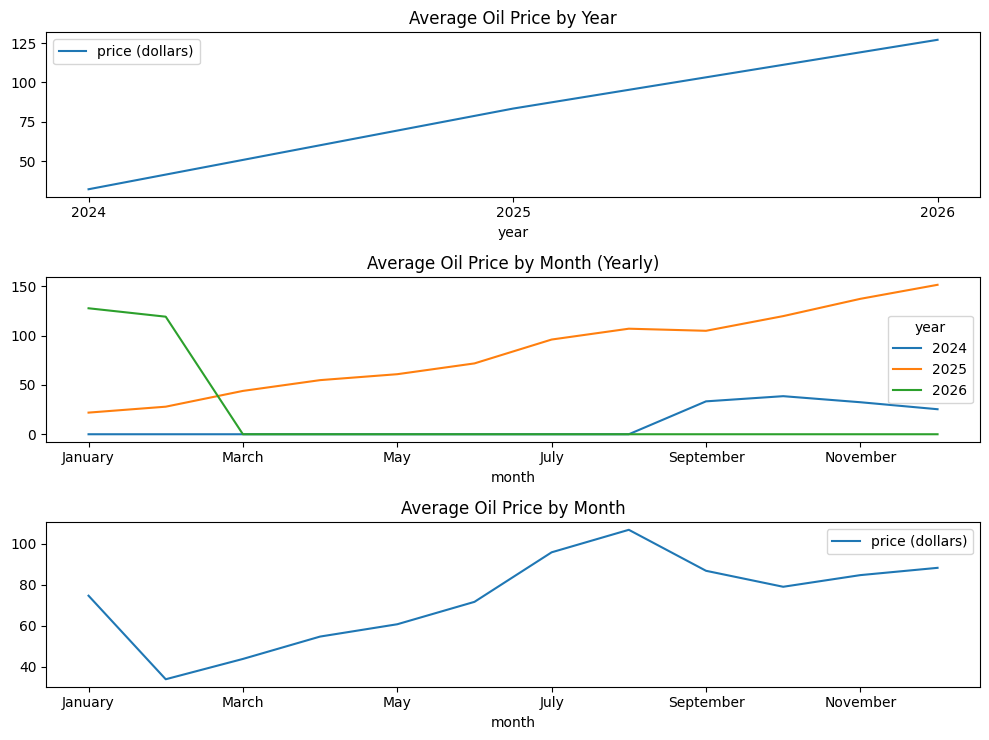

In [48]:
fig, ax = plt.subplots(nrows=3, ncols=1)

oil_year_mean.plot(ax=ax[0], title='Average Oil Price by Year')
ax[0].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
oil_month_mean_yearly.plot(ax=ax[1], title='Average Oil Price by Month (Yearly)')
oil_month_mean.plot(ax=ax[2], title='Average Oil Price by Month')

plt.tight_layout()
plt.show()

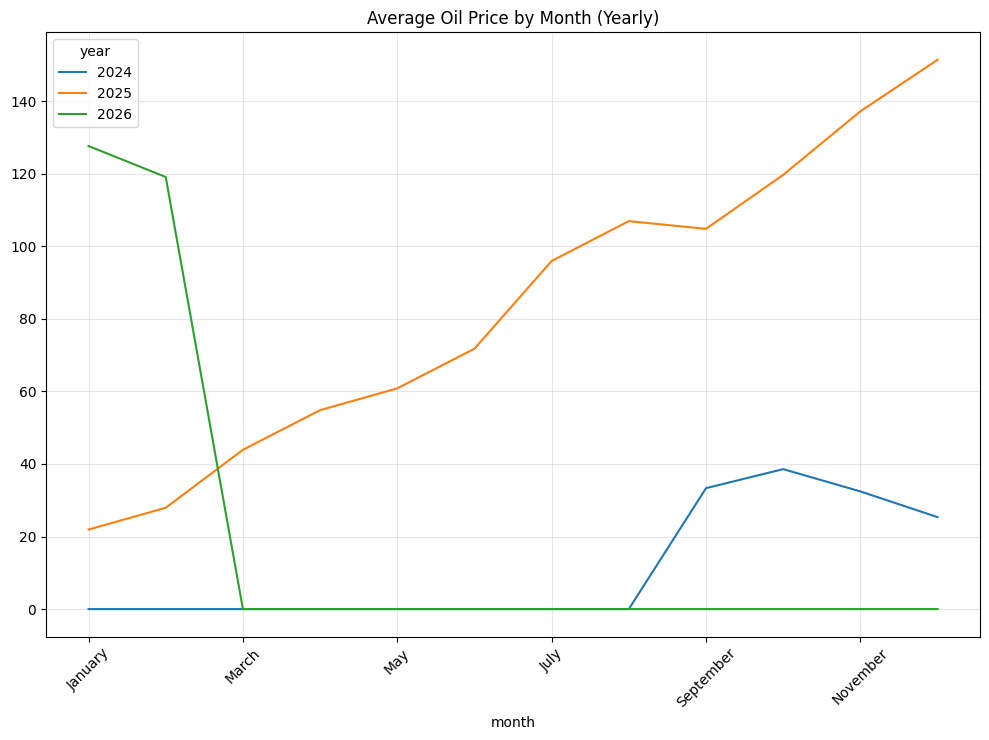

In [49]:
oil_month_mean_yearly.plot(title='Average Oil Price by Month (Yearly)')
plt.grid(True, axis='both', alpha=0.3)
plt.xticks(rotation=45) # Rotate x-axis labels
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [50]:
# Testing for stationarity using augmented dickey fuller test
data = oil.values
result = adfuller(data)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items(): print('\t%s: %.3f' % (key, value))

ADF Statistic: -0.546234
p-value: 0.882674
Critical Values:
	1%: -3.444
	5%: -2.868
	10%: -2.570


In [51]:
result = adfuller(oil.diff().dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items(): print('\t%s: %.3f' % (key, value))

ADF Statistic: -4.541460
p-value: 0.000165
Critical Values:
	1%: -3.444
	5%: -2.868
	10%: -2.570


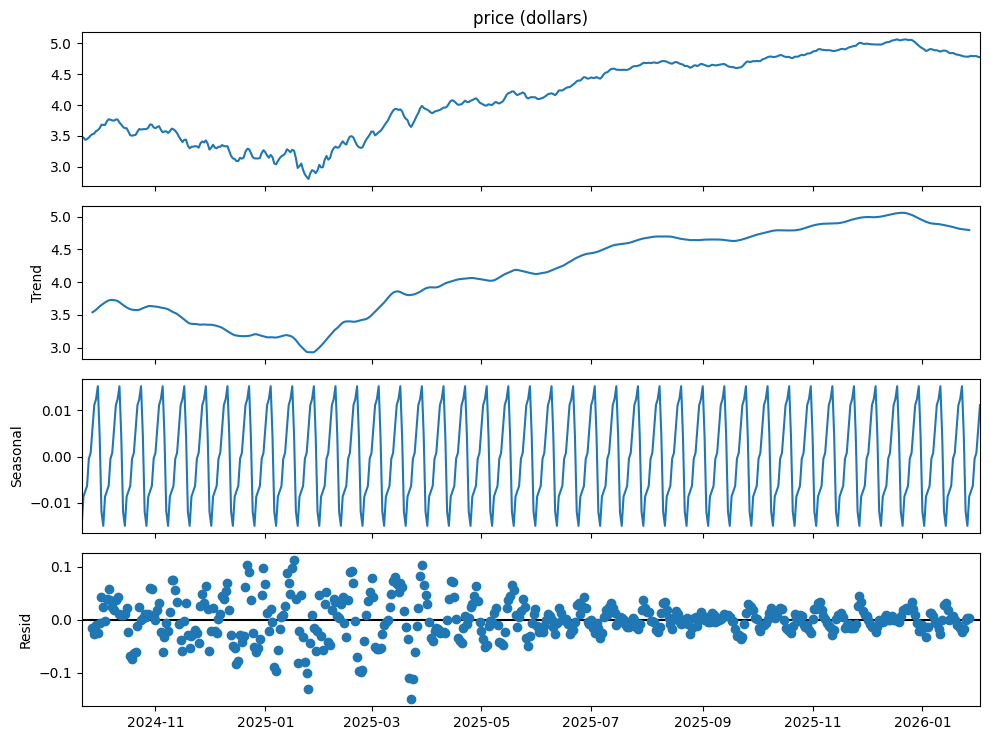

In [61]:
# Load your data into a Series named 'df'
# For Additive:
# result_add = seasonal_decompose(oil['price (dollars)'], model='additive', period=12)

# For Multiplicative:
#result_mult = seasonal_decompose(oil['price (dollars)'], model='multiplicative', period=12)
result_mult = seasonal_decompose(np.log(oil['price (dollars)']), model='multiplicative', period=12)

result_mult.plot()
plt.show()